In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [3]:
df = pd.read_csv("US_Crime_Data.csv")

In [4]:
df.head()

,Date,Title,Organization,City,State,URL,Keyword,Summary
0,2/13/17 9:01,Pizza Hut driver who killed co-worker with sho...,LGBTQ Nation,Phoenix,AZ,http://www.lgbtqnation.com/2017/02/man-accused...,NaN,NaN
1,2/13/17 9:37,Residents of NJ township receiving KKK promoti...,New York Daily News,NaN,NaN,http://www.nydailynews.com/news/national/resid...,NaN,NaN
2,2/13/17 15:37,House OKs bill to expand Kentucky's hate crime...,FOX19,Cincinnati,OH,http://www.fox19.com/story/34494432/house-oks-...,NaN,NaN
3,2/13/17 16:56,"Amid Protests, 'Blue Lives Matter' Bill Passes...",89.3 WFPL,Louisville,KY,http://wfpl.org/amid-protests-blue-lives-matte...,NaN,NaN
4,2/13/17 18:37,Lafourche inmates charged with hate crimes in ...,Daily Comet,Thibodaux,LA,http://www.dailycomet.com/news/20170213/lafour...,NaN,NaN


In [5]:
df.shape

(6783, 8)

In [6]:
df.columns

Index(['Date', 'Title', 'Organization', 'City', 'State', 'URL', 'Keyword',
       'Summary'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6783 entries, 0 to 6782
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          6783 non-null   object
 1   Title         6782 non-null   object
 2   Organization  6783 non-null   object
 3   City          5616 non-null   object
 4   State         5538 non-null   object
 5   URL           6783 non-null   object
 6   Keyword       5607 non-null   object
 7   Summary       4527 non-null   object
dtypes: object(8)
memory usage: 424.1+ KB


In [8]:
df.describe()

,Date,Title,Organization,City,State,URL,Keyword,Summary
count,6783,6782,6783,5616,5538,6783,5607,4527
unique,5998,6595,2241,835,111,6706,5442,4227
top,12/8/17 17:18,Teen charged in videotaped beating pleads to h...,HuffPost,New York,NY,http://www.scsuntimes.com/news/20170825/depart...,aggravated beat brittany chicago covington cri...,by AP\tThis booking photo provided by the Chic...
freq,41,50,128,875,954,3,15,33


In [9]:
df.isnull().sum()

Date               0
Title              1
Organization       0
City            1167
State           1245
URL                0
Keyword         1176
Summary         2256
dtype: int64

In [10]:
df = df.drop(columns=['URL'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6783 entries, 0 to 6782
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          6783 non-null   object
 1   Title         6782 non-null   object
 2   Organization  6783 non-null   object
 3   City          5616 non-null   object
 4   State         5538 non-null   object
 5   Keyword       5607 non-null   object
 6   Summary       4527 non-null   object
dtypes: object(7)
memory usage: 371.1+ KB


In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y %H:%M', errors='coerce')

In [13]:
df = df.dropna(subset=['Date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6782 entries, 0 to 6782
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6782 non-null   datetime64[ns]
 1   Title         6781 non-null   object        
 2   Organization  6782 non-null   object        
 3   City          5615 non-null   object        
 4   State         5537 non-null   object        
 5   Keyword       5606 non-null   object        
 6   Summary       4526 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 423.9+ KB


In [15]:
df[['City', 'State', 'Title']] = df[['City', 'State', 'Title']].fillna('Unknown')

In [16]:
df = df.drop_duplicates()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6724 entries, 0 to 6782
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6724 non-null   datetime64[ns]
 1   Title         6724 non-null   object        
 2   Organization  6724 non-null   object        
 3   City          6724 non-null   object        
 4   State         6724 non-null   object        
 5   Keyword       5551 non-null   object        
 6   Summary       4471 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 420.2+ KB


In [18]:
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

In [24]:
df['City_Freq'] = df['City'].map(df['City'].value_counts())
df['State_Freq'] = df['State'].map(df['State'].value_counts())

In [20]:
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
text_matrix = tfidf.fit_transform(df['Title'])

In [21]:
svd = TruncatedSVD(n_components=3, random_state=42)
text_features = svd.fit_transform(text_matrix)

In [22]:
text_df = pd.DataFrame(text_features, columns=['Text_1', 'Text_2', 'Text_3'])

In [26]:
numeric_cols = ['Hour', 'DayOfWeek', 'Is_Weekend', 'City_Freq', 'State_Freq']
X_numeric = df[numeric_cols].reset_index(drop=True)
X_combined = pd.concat([X_numeric, text_df], axis=1)

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [29]:
k_sil = silhouette_score(X_scaled, df['KMeans_Cluster'])

In [30]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [32]:
db_labels = df['DBSCAN_Cluster']

In [33]:
if len(set(db_labels)) > 1:
    db_sil = silhouette_score(X_scaled, db_labels)
else:
    db_sil = 0

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [37]:
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Text(0, 0.5, 'PCA 2')

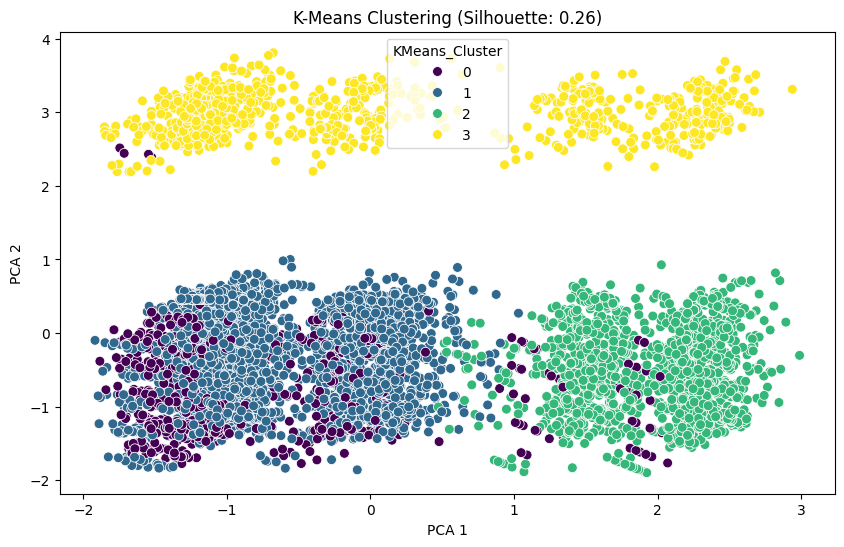

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['KMeans_Cluster'],
    palette='viridis',
    s=50
)
plt.title(f"K-Means Clustering (Silhouette: {k_sil:.2f})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

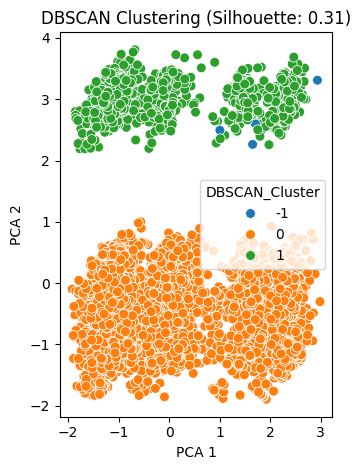

In [39]:
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['DBSCAN_Cluster'],
    palette='tab10',
    s=50
)
plt.title(f"DBSCAN Clustering (Silhouette: {db_sil:.2f})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

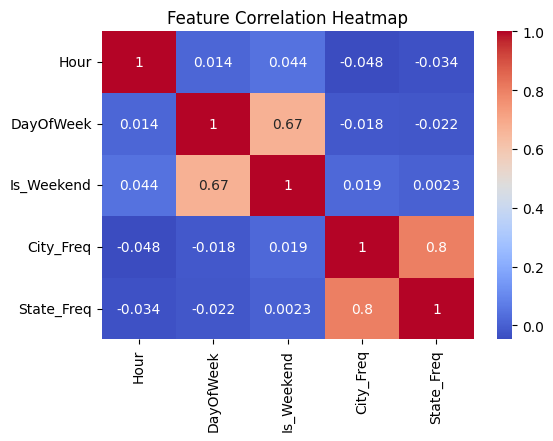

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(X_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
inertia = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

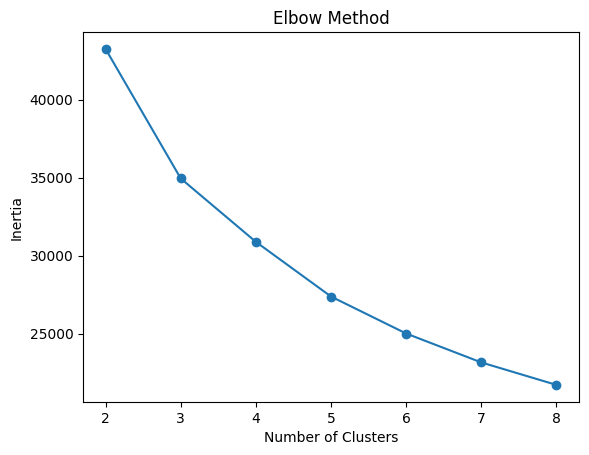

In [43]:
plt.plot(range(2, 9), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [44]:
print("\n--- FINAL PROJECT REPORT ---")
print(f"K-Means Silhouette Score: {k_sil:.4f}")
print(f"DBSCAN Silhouette Score: {db_sil:.4f}")
print(f"KMeans Clusters: {set(df['KMeans_Cluster'])}")
print(f"DBSCAN Clusters: {set(map(int, df['DBSCAN_Cluster']))}")


--- FINAL PROJECT REPORT ---
K-Means Silhouette Score: 0.2573
DBSCAN Silhouette Score: 0.3083
KMeans Clusters: {0, 1, 2, 3}
DBSCAN Clusters: {0, 1, -1}


In [45]:
print("\nCluster-wise Analysis (KMeans):")
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))


Cluster-wise Analysis (KMeans):
                     Hour  DayOfWeek  Is_Weekend    City_Freq   State_Freq  \
KMeans_Cluster                                                               
0               11.304248   1.869116    0.004592   135.647532   304.608496   
1               11.502674   2.073975    0.000000    74.232917   275.721925   
2               10.885768   1.878901    0.000000  1042.614232  1116.340824   
3               11.978531   5.529944    1.000000   376.604520   516.393220   

                DBSCAN_Cluster  
KMeans_Cluster                  
0                     0.004592  
1                     0.000000  
2                    -0.000624  
3                     0.986441  


In [1]:
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="crime_mapper")
df['Coordinates'] = df['City'] + ", " + df['State']
df['Location'] = df['Coordinates'].apply(lambda x: geolocator.geocode(x))
df['Latitude'] = df['Location'].apply(lambda loc: loc.latitude if loc else np.nan)
df['Longitude'] = df['Location'].apply(lambda loc: loc.longitude if loc else np.nan)

NameError: name 'df' is not defined